# Patient-level SHAP - explaining the pivot model (item 2)
All earlier SHAP/LIME was on the old visit-level models; this explains the NEW
patient-level within-30d model. Uses XGBoost's exact TreeSHAP (native pred_contribs).
Reads `patient_first_visit.csv`.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier, DMatrix

DATA_DIR = "/Users/robert/Desktop/hospital-re-admission/data/processed"
RESULTS_DIR = "/Users/robert/Desktop/hospital-re-admission/notebooks/17_patient_shap"
SEED = 42

## Train the within-30d model
Same model as NB14b so the explanation matches the reported scores.
Categoricals encoded on train only.

In [7]:
df = pd.read_csv(f"{DATA_DIR}/patient_first_visit.csv")
cat_cols = ["gender", "race", "marital_status", "language", "insurance",
            "admission_type", "admission_location", "discharge_location"]
drop_cols = ["subject_id", "hadm_id", "tgt_bucket", "tgt_days", "visit_num", "split"]
features = [c for c in df.columns if c not in drop_cols]
is_train = df["split"].values == "train"

X = df[features].copy()
for c in cat_cols:
    m = {v: i for i, v in enumerate(sorted(X.loc[is_train, c].astype(str).unique()))}
    X[c] = X[c].astype(str).map(m).fillna(-1).astype(int)
y = (df["tgt_days"] <= 30).fillna(False).astype(int).values

clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
                    colsample_bytree=0.8, eval_metric="logloss", tree_method="hist",
                    random_state=SEED, n_jobs=4)
clf.fit(X[is_train], y[is_train], sample_weight=compute_sample_weight("balanced", y[is_train]))

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Exact TreeSHAP
Use XGBoost's native pred_contribs (avoids a shap/XGBoost version clash).
Explain a 3,000-patient sample of the test set.

In [8]:
sample = X[~is_train].sample(3000, random_state=SEED)
contribs = clf.get_booster().predict(DMatrix(sample, feature_names=features), pred_contribs=True)
shap_values = contribs[:, :-1]  # last column is the bias term

mean_abs = pd.Series(np.abs(shap_values).mean(0), index=features).sort_values()
print("top drivers:")
print(mean_abs.tail(12).iloc[::-1].round(4).to_string())

top drivers:
los_hours             0.1912
admission_type        0.1223
discharge_location    0.1195
num_abnormal_labs     0.1096
race                  0.1079
num_medications       0.1067
num_lab_tests_24h     0.0955
hemoglobin_min        0.0847
antibiotic_flag       0.0753
num_diagnoses         0.0738
age                   0.0701
cci_cancer            0.0569


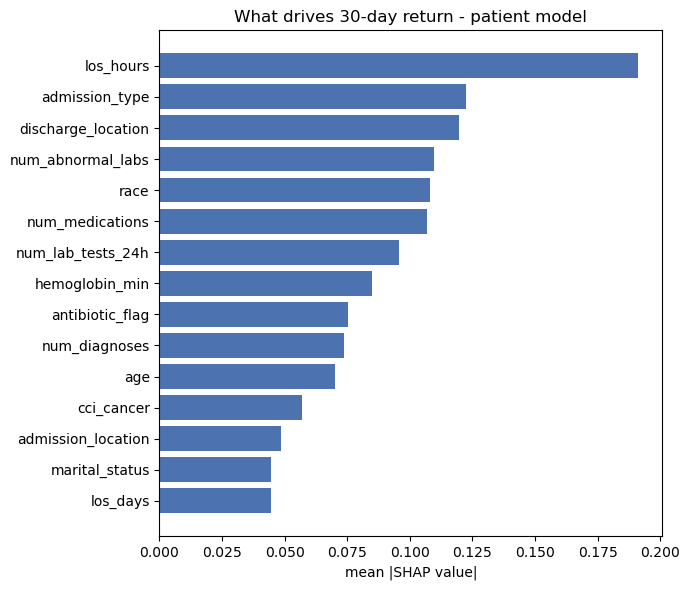

In [9]:
# Graph: mean |SHAP| bar (global feature importance for the pivot model).
top = mean_abs.tail(15)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color="#4c72b0")
ax.set_xlabel("mean |SHAP value|")
ax.set_title("What drives 30-day return - patient model")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/shap_bar_patient.png", dpi=150); plt.show()

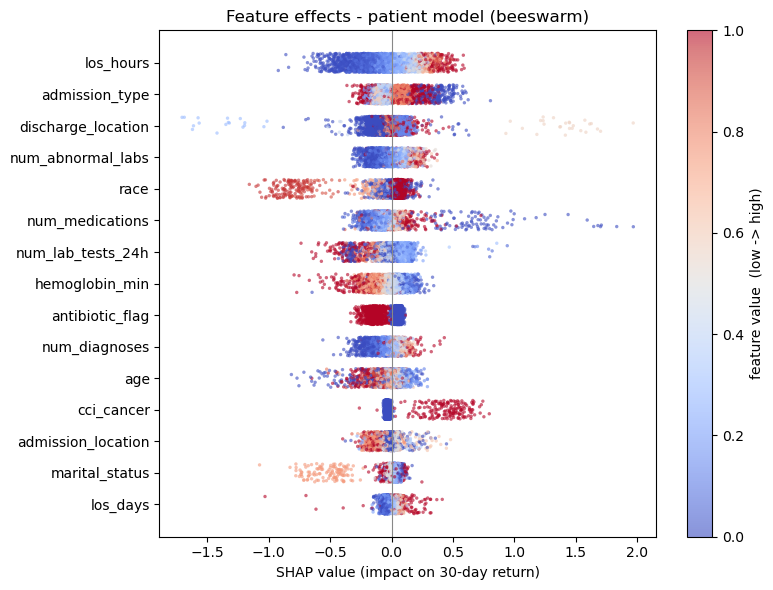

In [10]:
# Beeswarm WITHOUT the shap library (avoids the numba/coverage clash).
# SHAP values already come from XGBoost's native pred_contribs above.
order = mean_abs.tail(15).index  # ascending importance -> most important at top
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 6))
sc = None
for i, fname in enumerate(order):
    j = features.index(fname)
    sv_col = shap_values[:, j]
    fv = sample[fname].values.astype(float)
    lo, hi = np.percentile(fv, 5), np.percentile(fv, 95)
    cval = np.clip((fv - lo) / (hi - lo + 1e-9), 0, 1)
    yy = i + (rng.random(len(sv_col)) - 0.5) * 0.6
    sc = ax.scatter(sv_col, yy, c=cval, cmap="coolwarm", s=6, alpha=0.6, linewidths=0)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.axvline(0, color="#888", linewidth=0.8)
ax.set_xlabel("SHAP value (impact on 30-day return)")
ax.set_title("Feature effects - patient model (beeswarm)")
cb = plt.colorbar(sc, ax=ax); cb.set_label("feature value  (low -> high)")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/shap_beeswarm_patient.png", dpi=150, bbox_inches="tight"); plt.show()

## Note: SHAP importance is not predictive necessity
Race ranks highly by SHAP, but the ablation (NB_fairness) showed removing it costs
only ~0.006 AUROC - other features carry nearly the same information.